### Графики графики графики графики

В этом ноутбуке будем подробно разбирать разные типы графиков и как их строить.

Когда нужно построить какой-то график, и вы не знаете, что выбрать, у `matplotlib` есть ресурс с примерами графиков: https://matplotlib.org/stable/gallery/index. Часть примеров оттуда как раз и разобрана тут.

<div class="alert alert-block alert-warning" style="margin-top: 20px">

<font size=4>**Задание 1**</font>     

В файле `data/51_peg_b.txt` лежат данные о лучевой скорости звезды 51 Peg. Построить график этой лучевой скорости. Описания колонок есть в самом файле.

</div>

<details>
<summary>А где берутся такие данные?</summary>

Данные взяты отсюда: https://exoplanetarchive.ipac.caltech.edu/overview/51%20Peg%20b#planet_51-Peg-b_collapsible

Для других планет можно глянуть тут: https://exoplanetarchive.ipac.caltech.edu/cgi-bin/TblView/nph-tblView?app=ExoTbls&config=PS

</details>

In [ ]:
import matplotlib.pyplot as plt

days = []
vels = []
first_day = 0

with open("data/51_peg_b.txt") as file:
    for line in file.readlines()[3:]:
        vals = line.split(" ")
        vals_nonempty = []
        for val in vals:
            if val != "":
                vals_nonempty.append(val)

        day, vel, vel_err = vals_nonempty
        day = float(day)
        if first_day == 0:
            first_day = day
        
        vel = float(vel)

        days.append(day - first_day)
        vels.append(vel)

plt.plot(days, vels, linestyle = "None", marker = ".")
plt.show()

#### Ошибки

На графиках настоящих вычислений важно показывать интервал уверенности в каждом значении - оно же называется ошибками вычисления/измерения.

Для их построения в `matplotlib` есть специальная функция `errorbar`:

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(0, 100, 50)
y_err = np.random.uniform(0, 1000, 50)
y = x ** 2 + (100 - x) ** 1.8 + y_err / 2

plt.plot(x, y, marker=".", linestyle="None")
plt.errorbar(x, y, y_err, marker="None", linestyle="None")
plt.show()

Обратите внимание: чаще всего, если есть ошибки измерений, то для читаемости лучше не рисовать линии, соединяющие точки между собой. Они, чаще всего, не дают никакой пользы и только зашумляют изображение. 

<div class="alert alert-block alert-warning" style="margin-top: 20px">

<font size=4>**Задание 2**</font>

Построить ошибки лучевых скоростей на графике из задания 1.

</div>

In [ ]:
import matplotlib.pyplot as plt

days = []
vels = []
vel_errs = []
first_day = 0

with open("data/51_peg_b.txt") as file:
    for line in file.readlines()[3:]:
        vals = line.split(" ")
        vals_nonempty = []
        for val in vals:
            if val != "":
                vals_nonempty.append(val)
        
        day, vel, vel_err = vals_nonempty
        day = float(day)
        if first_day == 0:
            first_day = day
        
        vel = float(vel)
        vel_err = float(vel_err)

        days.append(day - first_day)
        vels.append(vel)
        vel_errs.append(vel_err)

plt.plot(days, vels, linestyle="None", marker=".")
plt.errorbar(days, vels, yerr=vel_errs, linestyle="None")
plt.show()

#### Дополнительные обозначения на графиках

##### Текст

Добавить текст на график в определённых координатах можно функцией `text`:

```python
plt.text(10, 20, "Текст")
```

Первый аргумент - x-координата, второй - y-координата, третий - текст, который нужно написать.

##### Вертикальные и горизонтальные линии

Нарисовать вертикальную линию по координате x = 40:

```python
plt.axvline(40)
```

Горизонтальную на координате y = 50:

```python
plt.axhline(50)
```

In [ ]:
# рисуем график из примеров выше опять

plt.text(40, 5000, "Точка")
plt.axhline(5000)
plt.axvline(40)

plt.plot(x, y, marker=".", linestyle="None")
plt.errorbar(x, y, y_err, marker="None", linestyle="None")
plt.show()

<div class="alert alert-block alert-warning" style="margin-top: 20px">

<font size=4>**Задание 3**</font>

Считая, что период обращения 4.23 дня, построить вертикальные линии, показывающие границы периодов.

</div>

In [ ]:
import matplotlib.pyplot as plt

days = []
vels = []
vel_errs = []
first_day = 0
period = 4.23

with open("data/51_peg_b.txt") as file:
    for line in file.readlines()[3:]:
        vals = line.split(" ")
        vals_nonempty = []
        for val in vals:
            if val != "":
                vals_nonempty.append(val)
        
        day, vel, vel_err = vals_nonempty
        day = float(day)
        if first_day == 0:
            first_day = day
        
        vel = float(vel)
        vel_err = float(vel_err)

        days.append(day - first_day)
        vels.append(vel)
        vel_errs.append(vel_err)

nth_period = 0.1
while nth_period * period < days[-1]:
    plt.axvline(nth_period * period)
    nth_period += 1

plt.plot(days, vels, linestyle="None", marker=".")
plt.errorbar(days, vels, yerr=vel_errs, linestyle="None")
plt.show()

### Диаграммы рассеяния

До сих пор мы строили графики, каждая точка которого показывает информацию о двух координатах. Что если у нас три координаты?

Примеры:
- Возраст звезды в зависимости от её положения в галактической плоскости
- Зависимость дохода от ожидаемой продолжительности жизни в разных странах:

    ![](images/income-lifeexp.png)
- Зависимость длины и ширины лепестков от вида ириса:

    ![](images/iris.png)

`matplotlib` позволяет нам строить такие графики. Для такого построения нам нужно два списка и цвет:
- x-координаты
- y-координаты
- название цвета

Получим следующее:

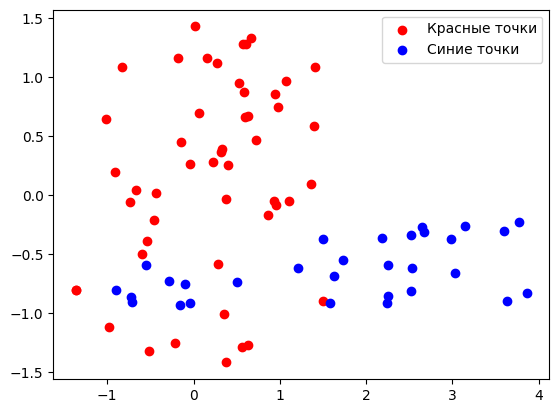

In [12]:
import matplotlib.pyplot as plt
import numpy as np

xs = np.random.uniform(-1.5, 1.5, 50)
ys = np.random.uniform(-1.5, 1.5, 50)

plt.scatter(xs, ys, color="red", label="Красные точки")

# Можно накладывать графики друг на друга, чтобы получить несколько

xs2 = np.random.uniform(-1.0, 4, 30)
ys2 = np.random.uniform(-1, -0.2, 30)

plt.scatter(xs2, ys2, color="blue", label="Синие точки")

plt.legend()
plt.show()

### Чтение CSV файлов при помощи `numpy`

Раньше мы читали CSV-файлы руками - это требует открытия файла и ручного преобразования каждой строки. Таким образом, даже чтение самого простого файла требует написания как минимум следующих строк (если есть файл `myfile.csv` с двумя столбцами, второй из которых - число с плавающей точкой):

```python
column1 = []
column2 = []

with open("myfile.csv") as file:
    lines = file.readlines()
    for line in lines:
        col1, col2 = line.split(",")
        column1.append(col1)
        column2.append(float(col2))
```

Чтобы не писать это каждый раз, `numpy` предоставляет удобную функцию - `genfromtxt`:

In [14]:
import numpy as np

# Если в первой строке файла есть названия столбцов
arr = np.genfromtxt(
    "data/hr.csv",
    delimiter=",", # разделитель между столбцами
    names=True,
    dtype=None,
)

rv = arr["rv"]
absmag = arr["absmag"]
print(rv)
print(absmag)

# Если в первой строке нет названий
arr = np.genfromtxt(
    "../01_numpy/data/sga.csv",
    delimiter=",", # разделитель между столбцами
    names=["name", "ra", "dec"],
    dtype=None,
)

print(arr["name"])

[  0.   0.   0. ... -15.   4.  13.]
[  4.85    2.39    5.866 ... -13.62  -13.16  -12.9  ]
['PGC690033' 'PGC1280588' 'PGC1529409' ... 'PGC013233' 'PGC898037'
 'PGC092735']


<div class="alert alert-block alert-warning" style="margin-top: 20px">

<font size=4>**Задание 4**</font>

В файле `data/hr.csv` лежат собранные в одном месте данные о звёздах из каталогов:
- Hipparcos
- Yale Bright Star
- Gliese

<details>
<summary>Откуда?</summary>

HYG Database: https://www.astronexus.com/projects/hyg

</details>

Построить диграмму Герцшпрунга-Рассела по этим данным, закодировав в цвете точек класс светимости объектов. Релевантные колонки:
- Показатель цвета: `ci`
- Абсолютная звёздная величина: `absmag`
- Светимость: `lum`
- Класс светимости: `luminosity_class`

Обратите внимание, что класс светимости есть не для всех объектов.

</div>

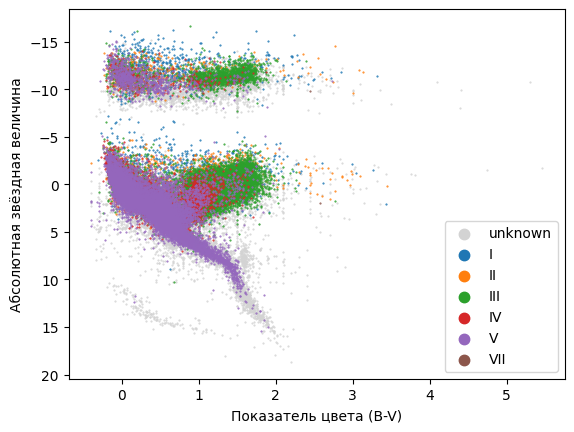

In [1]:
import numpy as np
import matplotlib.pyplot as plt

arr = np.genfromtxt(
    "data/hr.csv",
    delimiter=",",
    names=True,
    dtype=None,
)

absmag = arr["absmag"]
ci = arr["ci"]
lum_class = arr["luminosity_class"]

mask = lum_class != ""
plt.scatter(ci[~mask], absmag[~mask], marker=".", s=1, c="lightgrey", label="unknown")

for mc in ["I", "II", "III", "IV", "V", "VII"]:
    m = lum_class == mc
    if m.any():
        plt.scatter(ci[m], absmag[m], marker=".", s=1, label=mc)

plt.gca().invert_yaxis()
plt.xlabel("Показатель цвета (B-V)")
plt.ylabel("Абсолютная звёздная величина")
plt.legend(markerscale=15)

In [ ]:
import numpy as np
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt

arr = np.genfromtxt(
    "data/hr.csv",
    delimiter=",",
    names=True,
    dtype=None,
)

absmag = arr["absmag"]
ci = arr["ci"]
lum_class = arr["luminosity_class"]

def bv_to_rgb(bv: np.ndarray) -> np.ndarray:
    bv = np.clip(bv, -0.4, 2.0)
    t = (bv + 0.4) / 2.4

    r = np.clip(np.where(t < 0.4, 0.6 + t, 1.0), 0, 1)
    g = np.clip(np.where(t < 0.4, 0.7 + 0.75 * t, 1.0 - 0.7 * (t - 0.4)), 0, 1)
    b = np.clip(np.where(t < 0.4, 1.0, 1.0 - 1.6 * (t - 0.4)), 0, 1)

    rgb = np.column_stack([r, g, b])
    rgb = rgb / rgb.max(axis=1, keepdims=True)
    return rgb

fig, ax = plt.subplots(figsize=(10, 8), facecolor="black")
ax.set_facecolor("black")

classes = ["unknown", "I", "II", "III", "IV", "V", "VII"]
class_hex = {
    "unknown": "#8a8794",
    "I": "#0a1f4a",
    "II": "#7a1020",
    "III": "#1e6fd9",
    "IV": "#d0453a",
    "V": "#3dc7ff",
    "VII": "#ffb4a8",
}
class_colors = {c: mcolors.to_rgba(h) for c, h in class_hex.items()}

lum_mapped = np.where(lum_class == "", "unknown", lum_class)

glow_layers = [(40, 0.01), (20, 0.03), (8, 0.06)]

for mc in classes:
    m = lum_mapped == mc
    if not m.any():
        continue
    base_rgb = np.array(class_colors[mc][:3])
    for size, alpha in glow_layers:
        rgba = np.append(base_rgb, alpha)
        ax.scatter(ci[m], absmag[m], s=size, c=[rgba], marker="o", edgecolors="none")
    ax.scatter(ci[m], absmag[m], s=0.5, c=[class_colors[mc]], marker="o", edgecolors="none", label=mc)

ax.invert_yaxis()
ax.set_xlabel("Color index (B-V)", color="white")
ax.set_ylabel("Absolute magnitude", color="white")
ax.tick_params(colors="white")
for spine in ax.spines.values():
    spine.set_color("white")
ax.set_xlim(-0.5, 2.3)

legend = ax.legend(markerscale=15, facecolor="black", edgecolor="white", labelcolor="white")

plt.tight_layout()

### Гистограммы

### Логарифмическая шкала

### Фильтрация данных в `numpy`

<div class="alert alert-block alert-warning" style="margin-top: 20px">

<font size=4>**Задание 5**</font>

По данным этих же спектральных классов построить гистограмму числа звёзд в каждом классе. Использовать логарифмическую шкалу.

</div>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

arr = np.genfromtxt(
    "data/hr.csv",
    delimiter=",",
    names=True,
    dtype=None,
)

lum = arr["luminosity_class"]
lum_mapped = np.where(lum == "", "unknown", lum)
classes, counts = np.unique(lum_mapped, return_counts=True)

plt.bar(classes, counts)
plt.xlabel("Класс светимости")
plt.ylabel("Число звёзд")
plt.yscale("log")
plt.show()

### Диграмма рессеяния на небесной сфере

<div class="alert alert-block alert-warning" style="margin-top: 20px">

<font size=4>**Задание 6**</font>

В файле `data/sga.csv` лежат данные обзора Siena Galaxy Atlas (те же, что были в прошлом ноутбуке).

Построить диаграмму, показывающую каждый объект на небесной сфере.

</div>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

arr = np.genfromtxt(
    "data/sga.csv",
    delimiter=",",
    names=True,
    dtype=None,
)

ra_rad = np.deg2rad(np.mod(arr["ra"] + 180, 360) - 180)
dec_rad = np.deg2rad(arr["dec"])

fig, ax = plt.subplots(subplot_kw={"projection": "aitoff"})
ax.plot(ra_rad, dec_rad, ",", linestyle="none", markersize=0.5, alpha=0.2)
ax.grid(True)
plt.show()

### Построение карт и `imshow`

<div class="alert alert-block alert-warning" style="margin-top: 20px">

<font size=4>**Задание 7**</font>

В файле `data/gaia.csv` лежат данные плотности звёзд в окрестности Солнца. Данные расположены в двухмерной диаграмме - `x_kpc` и `y_kpc` - это координаты соответствующих бакетов этой диаграммы. Колонка `overdensity` содержит нормированное значение плотности. 

Построить карту плотности в окрестности Солнца, отметить Солнце в координатах 0,0.

</div>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

d = np.genfromtxt("data/gaia.csv", delimiter=",", names=True)
x_u, x_inv = np.unique(d["x_kpc"], return_inverse=True)
y_u, y_inv = np.unique(d["y_kpc"], return_inverse=True)
Z = np.zeros((len(y_u), len(x_u)))
Z[y_inv, x_inv] = d["overdensity"]

half = 0.5 * (x_u[1] - x_u[0])
extent = (x_u[0] - half, x_u[-1] + half, y_u[0] - half, y_u[-1] + half)

fig, ax = plt.subplots()
im = ax.imshow(
    Z,
    extent=extent,
    origin="lower",
    aspect="equal",
    cmap="viridis",
)
ax.plot(0, 0, marker="*", color="yellow", markersize=14, markeredgecolor="black")
ax.set_xlabel("x, kpc")
ax.set_ylabel("y, kpc")
fig.colorbar(im, ax=ax, label="overdensity")
plt.show()

### Графики в 3D

<div class="alert alert-block alert-warning" style="margin-top: 20px">

<font size=4>**Задание 8**</font>



</div>